# Diabetes Classification Using Artificial Neural Network (ANN)

## 1. Project Definition

### Objective

Build an Artificial Neural Network (ANN) using PyTorch to predict whether a person has diabetes based on medical and demographic features.

### Problem Type

Supervised Binary Classification.

### Dataset

Pima Indians Diabetes Dataset.

### Dataset Description

The dataset contains 768 observations with 8 input features and 1 target variable.

### Input Features

* Pregnancies
* Glucose
* BloodPressure
* SkinThickness
* Insulin
* BMI
* DiabetesPedigreeFunction
* Age

### Target Variable

Outcome:

* 0 → Negative
* 1 → Positive

### Technology Used

* Python
* NumPy
* Pandas
* Matplotlib
* Seaborn
* Scikit-learn
* PyTorch

### Project Goal

Build and evaluate a complete ANN-based binary classification pipeline, from data preprocessing and model training to final evaluation and inference.


In [1]:
# Import Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset

df = pd.read_csv("data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
# Data  Overview

df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df["BloodPressure"].sort_values().head(20)

597    24.0
18     30.0
125    30.0
599    38.0
4      40.0
575    44.0
741    44.0
80     44.0
576    44.0
707    46.0
346    46.0
75     48.0
405    48.0
293    48.0
117    48.0
97     48.0
508    50.0
647    50.0
98     50.0
313    50.0
Name: BloodPressure, dtype: float64

In [8]:
df["BloodPressure"].sort_values(ascending=False).head(20)

106    122.0
691    114.0
549    110.0
43     110.0
177    110.0
84     108.0
362    108.0
658    106.0
662    106.0
672    106.0
440    104.0
207    104.0
369    102.0
387    100.0
673    100.0
379    100.0
464     98.0
187     98.0
303     98.0
571     96.0
Name: BloodPressure, dtype: float64

In [9]:
(df["BloodPressure"] == 0).sum()

np.int64(0)

In [10]:
zero_counts = (df[[
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]] == 0).sum()

zero_counts


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

### Target Distribution

- Outcome = 0: 500 samples (65.10%)
- Outcome = 1: 268 samples (34.90%)
- The target classes are moderately imbalanced.
- Accuracy alone will not be sufficient for model evaluation.
- Precision, Recall, F1-score and ROC-AUC will also be considered.

## Exploratory Data Analysis (EDA)

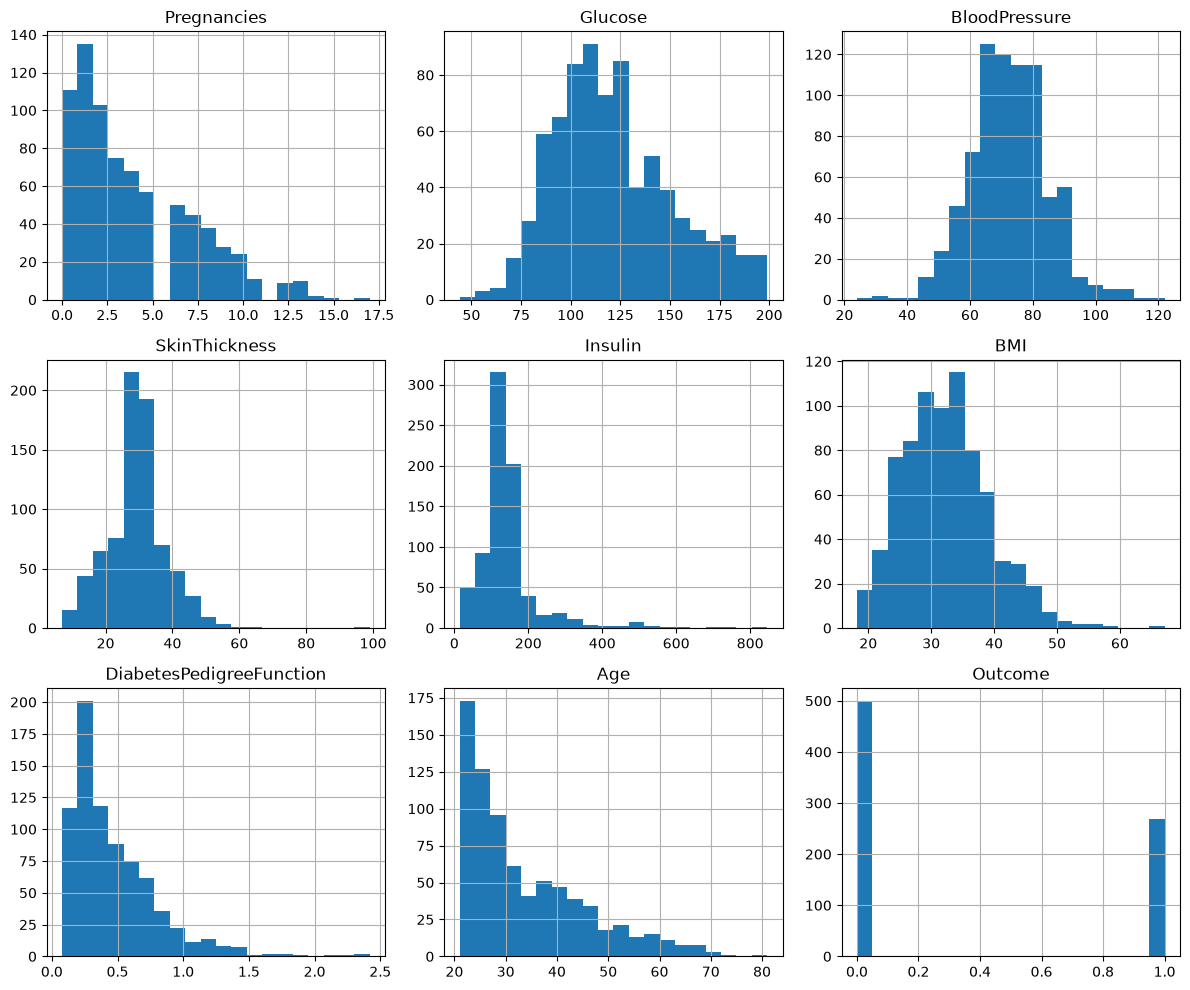

In [14]:
# Feature Distributions

df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

### Feature Distribution Findings

- Pregnancies is right-skewed.
- Glucose is approximately bell-shaped with some right skew.
- BloodPressure is approximately centered around 60–80 with extreme values at both ends.
- SkinThickness is right-skewed.
- Insulin is strongly right-skewed with a long right tail.
- BMI is approximately bell-shaped with some right skew.
- DiabetesPedigreeFunction is strongly right-skewed.
- Age is right-skewed.
- Outcome is moderately imbalanced, with class 0 being the majority class.

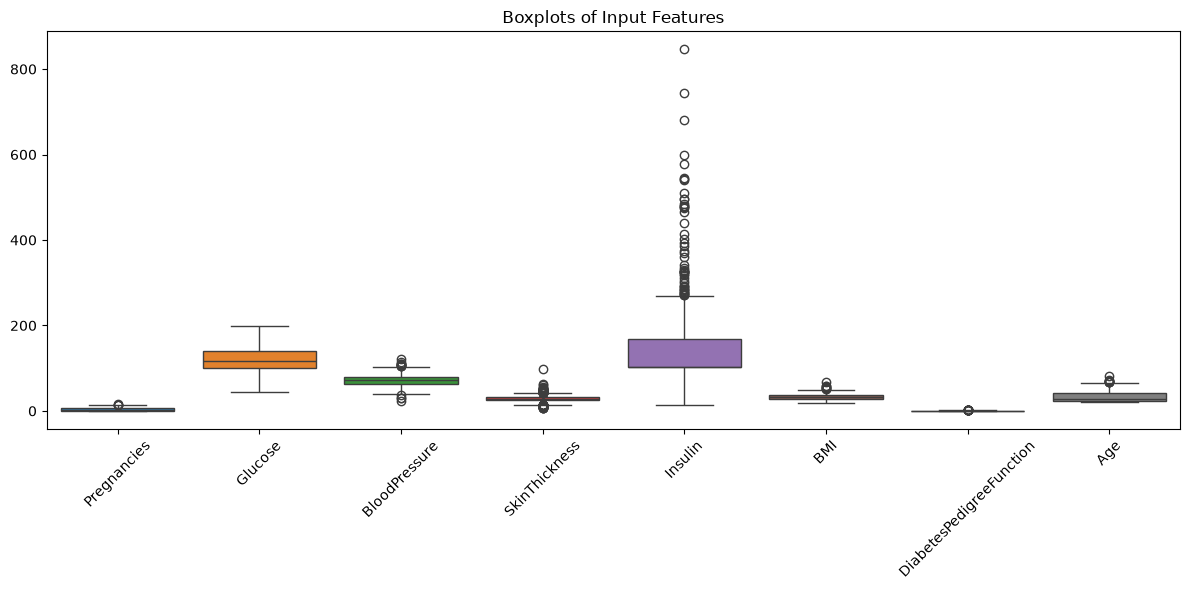

In [15]:
# Outlier Analysis

plt.figure(figsize=(12, 6))

sns.boxplot(data=df.drop(columns="Outcome"))

plt.xticks(rotation=45)
plt.title("Boxplots of Input Features")
plt.tight_layout()
plt.show()

### Outlier Analysis

- Outliers were identified using boxplots and the IQR-based visual criterion.
- Pregnancies, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction and Age contain some statistical outliers.
- Insulin contains the most prominent and numerous upper-end outliers.
- BloodPressure contains observations at both unusually low and high values.
- Statistical outliers are not automatically treated as erroneous observations.
- Outliers will be considered when selecting the preprocessing strategy.
- No observations are removed at this stage.

In [16]:


df.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.622000,70.844000,27.170000,117.172000,30.846000,0.429734,31.190000
1,4.865672,142.302239,75.272388,32.671642,187.615672,35.398507,0.550500,37.067164


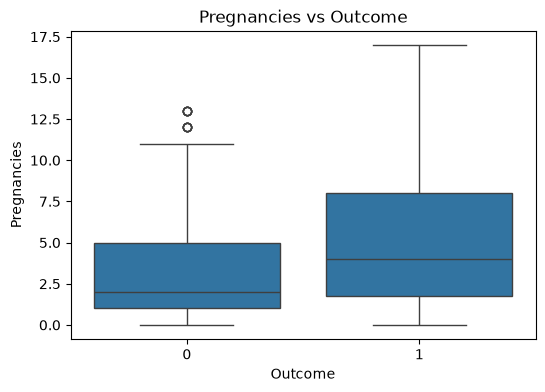

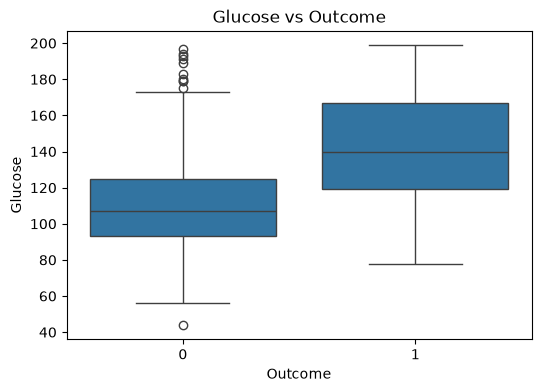

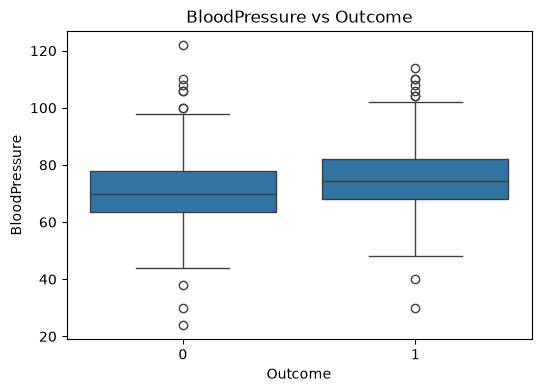

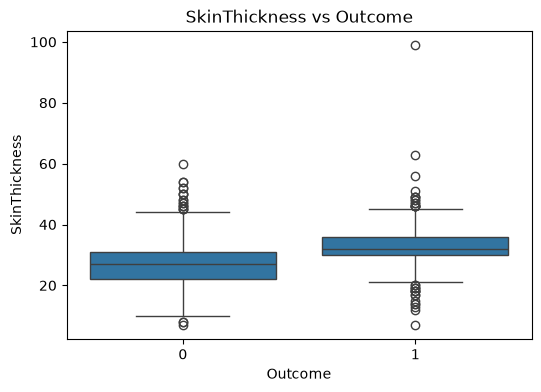

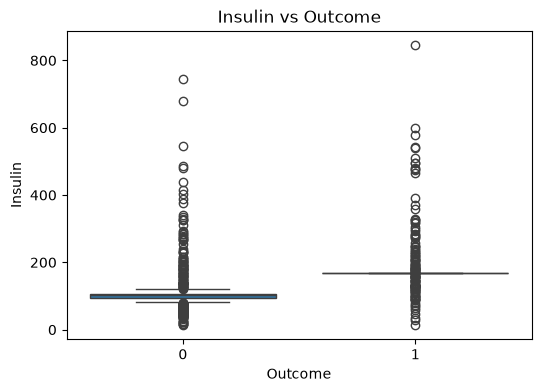

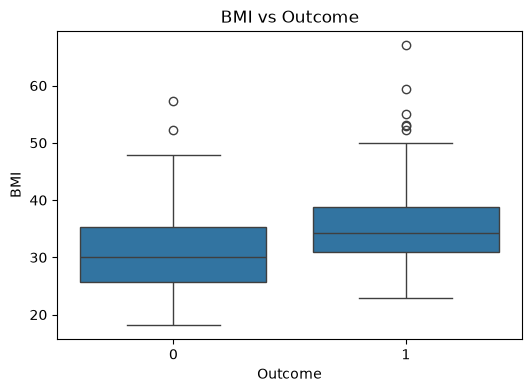

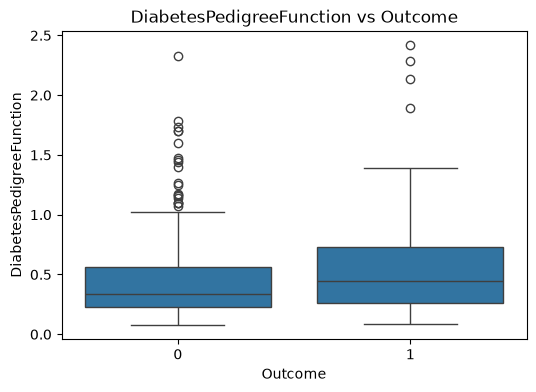

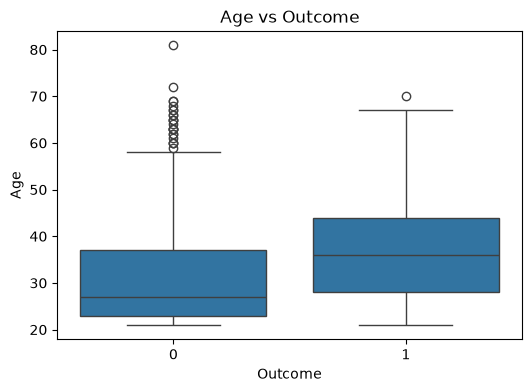

In [17]:
# Feature vs Outcome Analysis

features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Outcome", y=feature, data=df)
    plt.title(f"{feature} vs Outcome")
    plt.show()

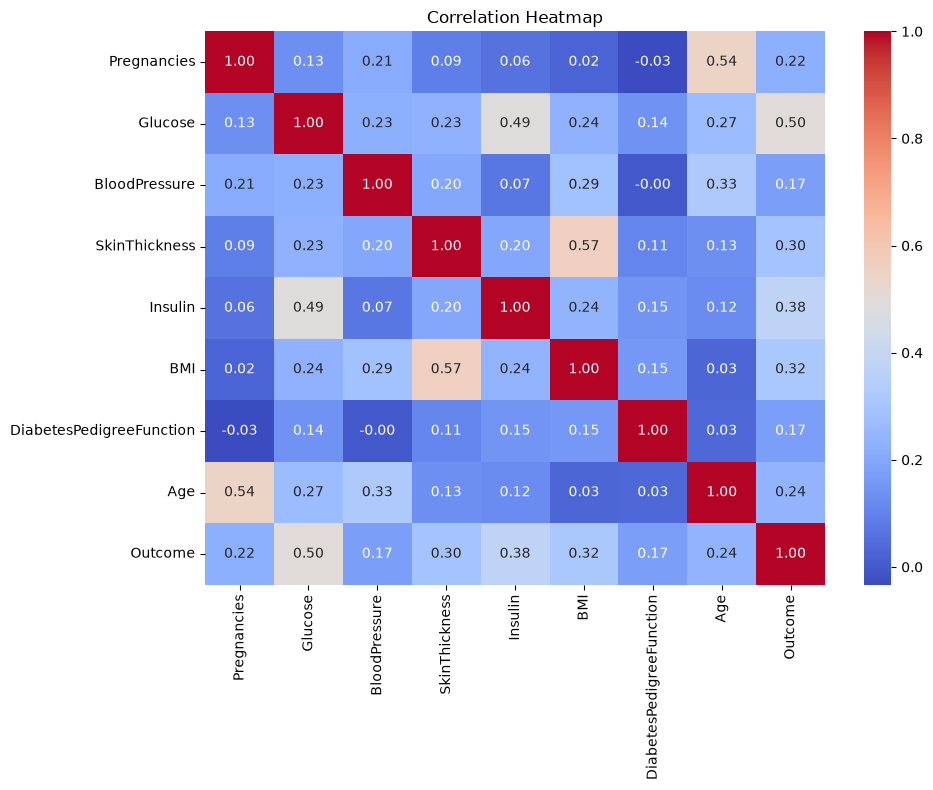

In [18]:
# Correlation Analysis

plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Analysis

- Glucose has the strongest linear correlation with Outcome (0.50).
- Insulin (0.38), BMI (0.32) and SkinThickness (0.30) also show noticeable positive correlations with Outcome.
- Age and Pregnancies have weaker positive correlations with Outcome.
- BloodPressure and DiabetesPedigreeFunction have relatively weak linear correlations with Outcome.
- Some feature-to-feature correlations exist, particularly SkinThickness-BMI and Pregnancies-Age.
- No feature is removed based only on correlation.
- Pearson correlation measures linear relationships and does not capture all nonlinear relationships or feature interactions.

### EDA Conclusions

- The dataset contains only numerical features.
- No missing/null values, duplicate rows, or zero values were found in the checked physiological features.
- Several features are right-skewed, especially Insulin and DiabetesPedigreeFunction.
- Multiple features contain statistical outliers, with Insulin showing the most prominent extreme values.
- Glucose shows the strongest relationship with the target and the clearest visual separation between the two outcome groups.
- BMI, Age, Pregnancies, Insulin and SkinThickness also show differences between the outcome groups.
- The target variable is moderately imbalanced (65.10% class 0 and 34.90% class 1).
- Feature correlations exist, but no feature will be removed solely based on Pearson correlation.
- Outliers will not be automatically removed because statistical outliers are not necessarily erroneous observations.
- Feature scaling will be required before ANN training because the input features have substantially different scales.

## Data Preprocessing

In [19]:
# Define X and y

X = df.drop(columns="Outcome")
y = df["Outcome"]

In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [21]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33


In [22]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

### Train / Validation / Test Split

In [23]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: devide the 30% temporary set equally
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [24]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)    

Training: (537, 8) (537,)
Validation: (115, 8) (115,)
Test: (116, 8) (116,)


In [25]:
print("Train:\n", y_train.value_counts(normalize=True))
print("\nValidation:\n", y_val.value_counts(normalize=True))
print("\nTest:\n", y_test.value_counts(normalize=True))

Train:
 Outcome
0    0.651769
1    0.348231
Name: proportion, dtype: float64

Validation:
 Outcome
0    0.652174
1    0.347826
Name: proportion, dtype: float64

Test:
 Outcome
0    0.646552
1    0.353448
Name: proportion, dtype: float64


### Feature Scaling

StandardScaler is used to standardize the numerical features.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [27]:
print("Training means:", X_train_scaled.mean(axis=0))
print("training std:", X_train_scaled.std(axis=0))

Training means: [ 2.31554895e-17 -5.95426874e-17  1.47202755e-16  5.62347603e-17
  9.26219581e-17  4.69725645e-16  1.19085375e-16 -2.11707333e-16]
training std: [1. 1. 1. 1. 1. 1. 1. 1.]


### Feature Scaling

StandardScaler was used to standardize all input features.

- The scaler was fitted only on the training data.
- Validation and test data were transformed using the same fitted scaler.
- This prevents data leakage.
- After scaling, training features have approximately:
  - Mean = 0
  - Standard deviation = 1

### Convert Data to PyTorch Tensors

The scaled feature arrays and target variables are converted into PyTorch tensors for model training.

In [28]:
import torch

In [29]:
# Convert feature
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

In [30]:
# Convert target
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [31]:
# Check tensors
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("\nX_train dtype:", X_train_tensor.dtype)
print("y_train dtype:", y_train_tensor.dtype)

X_train: torch.Size([537, 8])
y_train: torch.Size([537])

X_train dtype: torch.float32
y_train dtype: torch.float32


### PyTorch Dataset

A custom PyTorch Dataset is created to organize the input features and target labels for model training.

In [32]:
from torch.utils.data import Dataset, DataLoader

class DiabetesDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [33]:
# Create Dataset
train_dataset = DiabetesDataset(X_train_tensor, y_train_tensor)

val_dataset = DiabetesDataset(X_val_tensor, y_val_tensor)

test_dataset = DiabetesDataset(X_test_tensor, y_test_tensor)

In [34]:
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 537
Validation samples: 115
Test samples: 116


In [35]:
features, label = train_dataset[0]

print("Features:", features)
print("Label:", label)

Features: tensor([ 0.9314,  2.0848,  0.9657,  0.4932,  0.3702,  0.4311, -0.3748,  0.6321])
Label: tensor(1.)


### PyTorch Dataset

A custom PyTorch Dataset was created to organize features and labels.

The Dataset class implements:

- __init__(): Stores the input features and target labels.
- __len__(): Returns the total number of samples.
- __getitem__(): Returns one feature-label pair based on its index.

Separate Dataset objects were created for:

- Training data
- Validation data
- Test data

### PyTorch DataLoader

DataLoader is used to load the dataset in mini-batches during model training.

Mini-batch training allows the model to process a subset of samples at a time instead of the entire dataset at once.

In [36]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [37]:
X_batch, y_batch = next(iter(train_loader))

print("Feature batch shape:", X_batch.shape)
print("Label batch shape:", y_batch.shape)

Feature batch shape: torch.Size([32, 8])
Label batch shape: torch.Size([32])


## Build the Artificial Neural Network (ANN)

### ANN Architecture

The ANN architecture consists of:

8 Input Features → Hidden Layer (16 neurons) → Hidden Layer (8 neurons) → Output Layer (1 neuron)

ReLU activation is used in the hidden layers.

The output layer produces a raw logit. Sigmoid is handled internally by BCEWithLogitsLoss during training.

In [38]:
import torch.nn as nn

class DiabetesANN(nn.Module):

    def __init__(self):
        super(DiabetesANN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

In [39]:
# Create the Model

model = DiabetesANN()

print(model)

DiabetesANN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


### Loss Function and Optimizer

In [40]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [41]:
print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### Training and Validation Loop

In [42]:
epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(epochs):
    
    # ====================
    # Training Phase
    # ====================
    
    model.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        
        # Reshape labels: [batch_size] → [batch_size, 1]
        y_batch = y_batch.unsqueeze(1)
        
        # Forward pass
        outputs = model(X_batch)
        
        # Calculate loss
        loss = criterion(outputs, y_batch)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Store loss
        running_loss += loss.item() * X_batch.size(0)
        
        # Calculate accuracy
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()
        
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)
    
    
    epoch_train_loss = running_loss / total
    epoch_train_accuracy = correct / total
    
    
    # ====================
    # Validation Phase
    # ====================
    
    model.eval()
    
    running_val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        
        for X_batch, y_batch in val_loader:
            
            y_batch = y_batch.unsqueeze(1)
            
            outputs = model(X_batch)
            
            loss = criterion(outputs, y_batch)
            
            running_val_loss += loss.item() * X_batch.size(0)
            
            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()
            
            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    
    epoch_val_loss = running_val_loss / val_total
    epoch_val_accuracy = val_correct / val_total
    
    
    # Store metrics
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)
    
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Train Acc: {epoch_train_accuracy:.4f} | "
            f"Val Acc: {epoch_val_accuracy:.4f}"
        )        

Epoch [10/100] | Train Loss: 0.4400 | Val Loss: 0.4905 | Train Acc: 0.8082 | Val Acc: 0.7217
Epoch [20/100] | Train Loss: 0.3826 | Val Loss: 0.4849 | Train Acc: 0.8305 | Val Acc: 0.7565
Epoch [30/100] | Train Loss: 0.3597 | Val Loss: 0.4683 | Train Acc: 0.8380 | Val Acc: 0.7826
Epoch [40/100] | Train Loss: 0.3390 | Val Loss: 0.4372 | Train Acc: 0.8585 | Val Acc: 0.7826
Epoch [50/100] | Train Loss: 0.3250 | Val Loss: 0.4210 | Train Acc: 0.8641 | Val Acc: 0.8174
Epoch [60/100] | Train Loss: 0.3127 | Val Loss: 0.4084 | Train Acc: 0.8715 | Val Acc: 0.8261
Epoch [70/100] | Train Loss: 0.3036 | Val Loss: 0.4032 | Train Acc: 0.8790 | Val Acc: 0.8261
Epoch [80/100] | Train Loss: 0.2947 | Val Loss: 0.4007 | Train Acc: 0.8790 | Val Acc: 0.8348
Epoch [90/100] | Train Loss: 0.2864 | Val Loss: 0.4065 | Train Acc: 0.8845 | Val Acc: 0.8348
Epoch [100/100] | Train Loss: 0.2785 | Val Loss: 0.4093 | Train Acc: 0.8939 | Val Acc: 0.8348


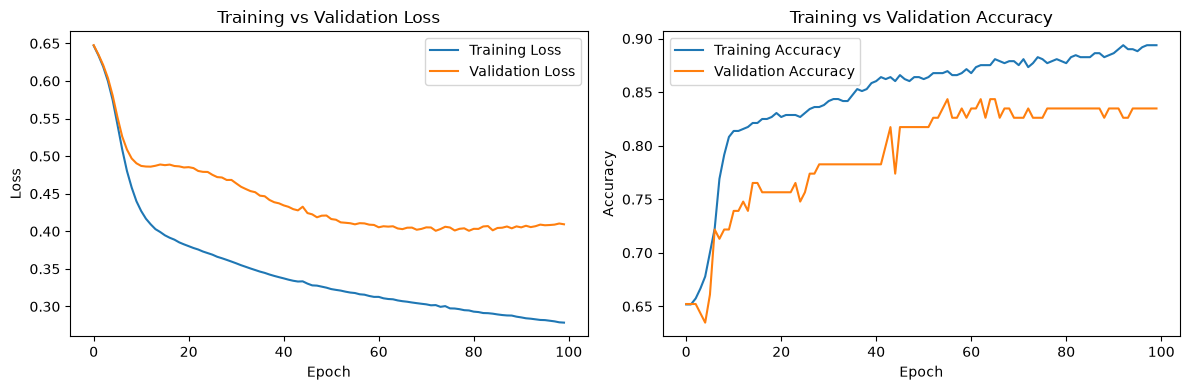

In [43]:
# Plot Training Curves

plt.figure(figsize=(12, 4))

# Loss Curve
plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()


# Accuracy Curve
plt.subplot(1, 2, 2)

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# Best Validation Epoch

best_epoch = np.argmin(val_losses) + 1

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", val_losses[best_epoch - 1])
print("Validation Accuracy:", val_accuracies[best_epoch - 1])

Best Epoch: 73
Best Validation Loss: 0.40066835206487905
Validation Accuracy: 0.8347826086956521


### Retrain ANN with Proper Model Checkpointing

In [45]:
torch.manual_seed(42)

In [46]:
# Recreate Model, loss Function and Optimizer

model = DiabetesANN()

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [47]:
# Training Loop with Checkpointing

import copy

epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# Best model tracking
best_val_loss = float("inf")
best_epoch = 0
best_model_weights = None


for epoch in range(epochs):
    
    # ====================
    # Training Phase
    # ====================
    
    model.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    
    for X_batch, y_batch in train_loader:
        
        # Reshape labels
        y_batch = y_batch.unsqueeze(1)
        
        # Forward pass
        outputs = model(X_batch)
        
        # Calculate loss
        loss = criterion(outputs, y_batch)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate loss
        running_loss += loss.item() * X_batch.size(0)
        
        # Accuracy
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()
        
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)
    
    
    epoch_train_loss = running_loss / total
    epoch_train_accuracy = correct / total
    
    
    # ====================
    # Validation Phase
    # ====================
    
    model.eval()
    
    running_val_loss = 0
    val_correct = 0
    val_total = 0
    
    
    with torch.no_grad():
        
        for X_batch, y_batch in val_loader:
            
            y_batch = y_batch.unsqueeze(1)
            
            outputs = model(X_batch)
            
            loss = criterion(outputs, y_batch)
            
            running_val_loss += loss.item() * X_batch.size(0)
            
            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()
            
            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    
    epoch_val_loss = running_val_loss / val_total
    epoch_val_accuracy = val_correct / val_total
    
    
    # ====================
    # Store Metrics
    # ====================
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    
    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)
    
    
    # ====================
    # Model Checkpointing
    # ====================
    
    if epoch_val_loss < best_val_loss:
        
        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1
        
        best_model_weights = copy.deepcopy(model.state_dict())
    
    
    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Train Acc: {epoch_train_accuracy:.4f} | "
            f"Val Acc: {epoch_val_accuracy:.4f}"
        )

Epoch [10/100] | Train Loss: 0.4727 | Val Loss: 0.4880 | Train Acc: 0.7840 | Val Acc: 0.7304
Epoch [20/100] | Train Loss: 0.4114 | Val Loss: 0.4606 | Train Acc: 0.8268 | Val Acc: 0.7304
Epoch [30/100] | Train Loss: 0.3567 | Val Loss: 0.4611 | Train Acc: 0.8510 | Val Acc: 0.7739
Epoch [40/100] | Train Loss: 0.3340 | Val Loss: 0.4505 | Train Acc: 0.8678 | Val Acc: 0.8000
Epoch [50/100] | Train Loss: 0.3184 | Val Loss: 0.4384 | Train Acc: 0.8715 | Val Acc: 0.7913
Epoch [60/100] | Train Loss: 0.3062 | Val Loss: 0.4285 | Train Acc: 0.8790 | Val Acc: 0.8000
Epoch [70/100] | Train Loss: 0.2948 | Val Loss: 0.4267 | Train Acc: 0.8771 | Val Acc: 0.8000
Epoch [80/100] | Train Loss: 0.2844 | Val Loss: 0.4292 | Train Acc: 0.8771 | Val Acc: 0.8000
Epoch [90/100] | Train Loss: 0.2757 | Val Loss: 0.4330 | Train Acc: 0.8883 | Val Acc: 0.7913
Epoch [100/100] | Train Loss: 0.2676 | Val Loss: 0.4359 | Train Acc: 0.8883 | Val Acc: 0.7913


In [48]:
# Restore the Best Model

model.load_state_dict(best_model_weights)

print(f"\nBest Model from Epoch: {best_epoch}")
print(f"Best Valiadtion Loss: {best_val_loss:.4f}")


Best Model from Epoch: 70
Best Valiadtion Loss: 0.4267


In [49]:
import copy

torch.manual_seed(42)

model = DiabetesANN()

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [50]:
epochs = 100

patience = 15
counter = 0

best_val_loss = float("inf")
best_epoch = 0
best_model_weights = None

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [51]:
for epoch in range(epochs):

    # ====================
    # Training Phase
    # ====================
    
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        y_batch = y_batch.unsqueeze(1)

        # Forward pass
        outputs = model(X_batch)

        # Loss
        loss = criterion(outputs, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_loss += loss.item() * X_batch.size(0)

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)


    epoch_train_loss = running_loss / total
    epoch_train_accuracy = correct / total


    # ====================
    # Validation Phase
    # ====================

    model.eval()

    running_val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            y_batch = y_batch.unsqueeze(1)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            val_correct += (predictions == y_batch).sum().item()
            val_total += y_batch.size(0)


    epoch_val_loss = running_val_loss / val_total
    epoch_val_accuracy = val_correct / val_total


    # Store metrics
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)


    # ====================
    # Checkpointing + Early Stopping
    # ====================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        best_model_weights = copy.deepcopy(model.state_dict())

        counter = 0

    else:

        counter += 1


    # Print progress
    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Train Acc: {epoch_train_accuracy:.4f} | "
            f"Val Acc: {epoch_val_accuracy:.4f}"
        )


    # Early stopping condition
    if counter >= patience:

        print(f"\nEarly stopping triggered at epoch {epoch + 1}")

        break 

Epoch [10/100] | Train Loss: 0.4727 | Val Loss: 0.4880 | Train Acc: 0.7840 | Val Acc: 0.7304
Epoch [20/100] | Train Loss: 0.4114 | Val Loss: 0.4606 | Train Acc: 0.8268 | Val Acc: 0.7304
Epoch [30/100] | Train Loss: 0.3567 | Val Loss: 0.4611 | Train Acc: 0.8510 | Val Acc: 0.7739
Epoch [40/100] | Train Loss: 0.3340 | Val Loss: 0.4505 | Train Acc: 0.8678 | Val Acc: 0.8000
Epoch [50/100] | Train Loss: 0.3184 | Val Loss: 0.4384 | Train Acc: 0.8715 | Val Acc: 0.7913
Epoch [60/100] | Train Loss: 0.3062 | Val Loss: 0.4285 | Train Acc: 0.8790 | Val Acc: 0.8000
Epoch [70/100] | Train Loss: 0.2948 | Val Loss: 0.4267 | Train Acc: 0.8771 | Val Acc: 0.8000
Epoch [80/100] | Train Loss: 0.2844 | Val Loss: 0.4292 | Train Acc: 0.8771 | Val Acc: 0.8000

Early stopping triggered at epoch 85


In [52]:
model.load_state_dict(best_model_weights)

print(f"\nBest Model from Epoch: {best_epoch}")
print(f"Best Validation Loss: {best_val_loss:.4f}")


Best Model from Epoch: 70
Best Validation Loss: 0.4267


### Final Model Evaluation

The final model is evaluated on the unseen test set.

The test set was not used during training, validation, model selection, or early stopping.

In [53]:
model.eval()

test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        # Reshape lables
        y_batch = y_batch.unsqueeze(1)

        # Forward pass
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, y_batch)

        test_loss += loss.item() * X_batch.size(0)

        # Convert logits to probabilites to predictions
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        test_correct += (predictions == y_batch).sum().item()
        test_total += y_batch.size(0)

final_test_loss = test_loss / test_total
final_test_accuracy = test_correct / test_total

print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_accuracy:.4f}")

Test Loss: 0.3054
Test Accuracy: 0.8793


In [54]:
all_predictions = []
all_probabilities = []
all_labels = []

model.eval()

with torch.no_grad():
    
    for X_batch, y_batch in test_loader:
        
        outputs = model(X_batch)
        
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).int()
        
        all_predictions.extend(
            predictions.squeeze(1).cpu().numpy().tolist()
        )
        
        all_probabilities.extend(
            probabilities.squeeze(1).cpu().numpy().tolist()
        )
        
        all_labels.extend(
            y_batch.cpu().numpy().tolist()
        )


# Convert to NumPy arrays
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_labels = np.array(all_labels)


print("Predictions shape:", all_predictions.shape)
print("Probabilities shape:", all_probabilities.shape)
print("Actual labels shape:", all_labels.shape)

Predictions shape: (116,)
Probabilities shape: (116,)
Actual labels shape: (116,)


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [56]:
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(all_labels, all_predictions)

recall = recall_score(all_labels, all_predictions)

f1 = f1_score(all_labels, all_predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8793
Precision: 0.8140
Recall: 0.8537
F1 Score: 0.8333


In [57]:
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["No Diabetes", "Diabetes"]
    )
)


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.92      0.89      0.91        75
    Diabetes       0.81      0.85      0.83        41

    accuracy                           0.88       116
   macro avg       0.87      0.87      0.87       116
weighted avg       0.88      0.88      0.88       116



The ANN achieved 87.93% test accuracy, with an F1-score of 83.33% and recall of 85.37% for the Diabetes class.

### Confusion Matrix

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[67  8]
 [ 6 35]]


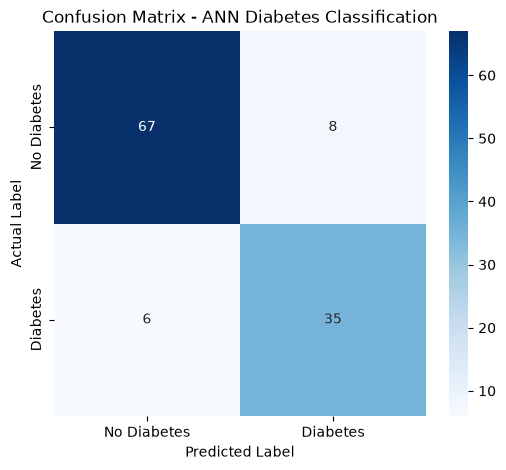

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - ANN Diabetes Classification")

plt.show()

In [60]:
# Calculate ROC-AUC
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thersholds = roc_curve(
    all_labels,
    all_probabilities
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9376


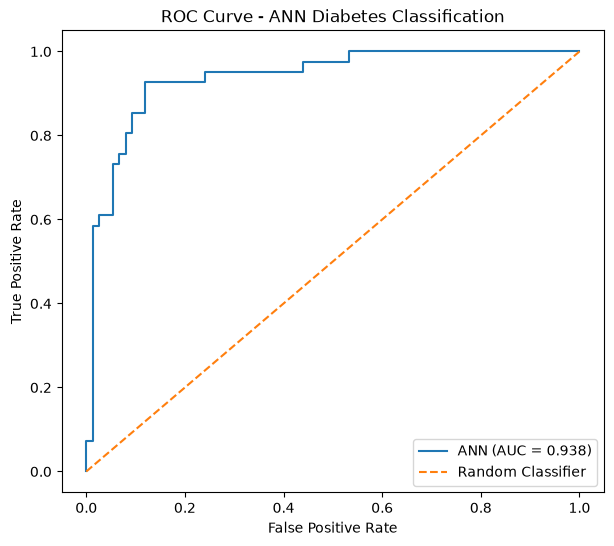

In [61]:
# Plot ROC Curve

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN Diabetes Classification")

plt.legend()
plt.show()

## Baseline Model Comparison

### Logistics Regression Baseline

In [62]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train);

In [63]:
val_predictions_lr = log_reg.predict(X_val_scaled)
val_probabilities_lr = log_reg.predict_proba(X_val_scaled)[:, 1]

print("Logistic Regression - Validation Results")

print(f"Accuracy: {accuracy_score(y_val, val_predictions_lr):.4f}")
print(f"F1 Score: {f1_score(y_val, val_predictions_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, val_probabilities_lr):.4f}")

Logistic Regression - Validation Results
Accuracy: 0.6957
F1 Score: 0.5570
ROC-AUC: 0.8047


### Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train);

In [65]:
val_predictions_rf = rf_model.predict(X_val)
val_probabilities_rf = rf_model.predict_proba(X_val)[:, 1]

print("Random Forest - Validation Results")

print(f"Accuracy: {accuracy_score(y_val, val_predictions_rf):.4f}")
print(f"F1 Score: {f1_score(y_val, val_predictions_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, val_probabilities_rf):.4f}")

Random Forest - Validation Results
Accuracy: 0.8522
F1 Score: 0.7848
ROC-AUC: 0.9250


### ANN Validation Metrics

In [66]:
ann_val_predictions = []
ann_val_probabilities = []
ann_val_labels = []

model.eval()

with torch.no_grad():
    
    for X_batch, y_batch in val_loader:
        
        outputs = model(X_batch)
        
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).int()
        
        ann_val_predictions.extend(
            predictions.squeeze(1).cpu().numpy().tolist()
        )
        
        ann_val_probabilities.extend(
            probabilities.squeeze(1).cpu().numpy().tolist()
        )
        
        ann_val_labels.extend(
            y_batch.cpu().numpy().tolist()
        )


ann_val_predictions = np.array(ann_val_predictions)
ann_val_probabilities = np.array(ann_val_probabilities)
ann_val_labels = np.array(ann_val_labels)

In [67]:
print("ANN - Validation Results")

print(f"Accuracy: {accuracy_score(ann_val_labels, ann_val_predictions):.4f}")
print(f"F1 Score: {f1_score(ann_val_labels, ann_val_predictions):.4f}")
print(f"ROC-AUC:  {roc_auc_score(ann_val_labels, ann_val_probabilities):.4f}")

ANN - Validation Results
Accuracy: 0.8000
F1 Score: 0.7356
ROC-AUC:  0.8840


### SVM Baseline

In [68]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train);

C:\Users\okavt\miniconda3\envs\deep_learning\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [69]:
val_predictions_svm = svm_model.predict(X_val_scaled)
val_probabilities_svm = svm_model.predict_proba(X_val_scaled)[:, 1]

print("SVM - Validation Results")

print(f"Accuracy: {accuracy_score(y_val, val_predictions_svm):.4f}")
print(f"F1 Score: {f1_score(y_val, val_predictions_svm):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, val_probabilities_svm):.4f}")

SVM - Validation Results
Accuracy: 0.7826
F1 Score: 0.6988
ROC-AUC:  0.8637


### Hyperparameter Tuning

In [70]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [71]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    
    "max_depth": [None, 5, 10, 15, 20],
    
    "min_samples_split": [2, 5, 10],
    
    "min_samples_leaf": [1, 2, 4],
    
    "max_features": ["sqrt", "log2", None],
    
    "class_weight": [None, "balanced"]
}

In [72]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [73]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [74]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a functi

In [75]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'class_weight': None}

Best Cross-Validation ROC-AUC:
0.9433611054663686


In [76]:
# Evaluate Tuned Random Forest on Validation Set

best_rf = random_search.best_estimator_

In [77]:
val_predictions_rf_tuned = best_rf.predict(X_val)

val_probabilities_rf_tuned = best_rf.predict_proba(X_val)[:, 1]

In [78]:
print("Tuned Random Forest - Validation Results")

print(f"Accuracy: {accuracy_score(y_val, val_predictions_rf_tuned):.4f}")
print(f"F1 Score: {f1_score(y_val, val_predictions_rf_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, val_probabilities_rf_tuned):.4f}")

Tuned Random Forest - Validation Results
Accuracy: 0.8522
F1 Score: 0.7848
ROC-AUC: 0.9277


In [79]:
# Final Test Evaluation on Tuned Random Forest

best_rf = random_search.best_estimator_

In [80]:
rf_test_predictions = best_rf.predict(X_test)

rf_test_probabilities = best_rf.predict_proba(X_test)[:, 1]

In [81]:
print("Tuned Random Forest - Test Results\n")

print(f"Accuracy: {accuracy_score(y_test, rf_test_predictions):.4f}")
print(f"Precision: {precision_score(y_test, rf_test_predictions):.4f}")
print(f"Recall: {recall_score(y_test, rf_test_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_test_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_test_probabilities):.4f}")

Tuned Random Forest - Test Results

Accuracy: 0.9138
Precision: 0.9189
Recall: 0.8293
F1 Score: 0.8718
ROC-AUC: 0.9551


In [82]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        rf_test_predictions,
        target_names=["No Diabetes", "Diabetes"]
    )
)


Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.91      0.96      0.94        75
    Diabetes       0.92      0.83      0.87        41

    accuracy                           0.91       116
   macro avg       0.92      0.89      0.90       116
weighted avg       0.91      0.91      0.91       116



### Random Forest Confusion Matrix

In [83]:
cm_rf = confusion_matrix(y_test, rf_test_predictions)

print(cm_rf)

[[72  3]
 [ 7 34]]


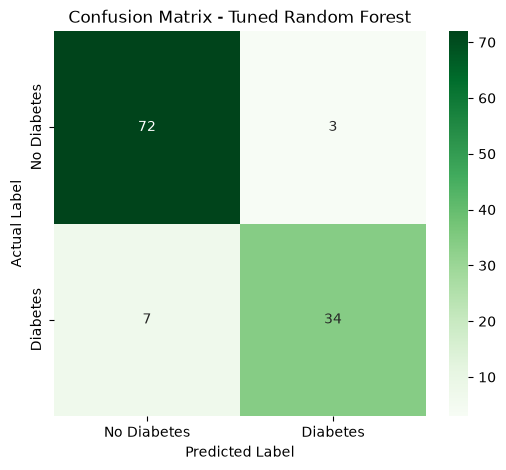

In [84]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Tuned Random Forest")

plt.show()

### Threshold Evaluation Function

In [85]:
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    
    predictions = (val_probabilities_rf_tuned >= threshold).astype(int)
    
    results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(y_val, predictions, zero_division=0),
        "Recall": recall_score(y_val, predictions, zero_division=0),
        "F1 Score": f1_score(y_val, predictions, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.721739,0.558824,0.950,0.703704
1,0.15,0.765217,0.603175,0.950,0.737864
2,0.20,0.773913,0.625000,0.875,0.729167
3,0.25,0.800000,0.660377,0.875,0.752688
4,0.30,0.834783,0.714286,0.875,0.786517
5,0.35,0.826087,0.717391,0.825,0.767442
6,0.40,0.834783,0.744186,0.800,0.771084
7,0.45,0.843478,0.761905,0.800,0.780488
8,0.50,0.852174,0.794872,0.775,0.784810
9,0.55,0.843478,0.789474,0.750,0.769231


In [86]:
selected_thresholds = [0.30, 0.50, 0.65]

for threshold in selected_thresholds:
    
    preds = (val_probabilities_rf_tuned >= threshold).astype(int)
    
    cm = confusion_matrix(y_val, preds)
    
    print(f"\nThreshold: {threshold}")
    print(cm)


Threshold: 0.3
[[61 14]
 [ 5 35]]

Threshold: 0.5
[[67  8]
 [ 9 31]]

Threshold: 0.65
[[72  3]
 [10 30]]


In [87]:
# Final Test Evaluation at Threshold = 0.30

threshold = 0.30

rf_test_predictions_030 = (
    rf_test_probabilities >= threshold
).astype(int)

In [88]:
print("Random Forest - Test Results (Threshold = 0.30)\n")

print(f"Accuracy:  {accuracy_score(y_test, rf_test_predictions_030):.4f}")
print(f"Precision: {precision_score(y_test, rf_test_predictions_030):.4f}")
print(f"Recall:    {recall_score(y_test, rf_test_predictions_030):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_test_predictions_030):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_test_probabilities):.4f}")

Random Forest - Test Results (Threshold = 0.30)

Accuracy:  0.9138
Precision: 0.8605
Recall:    0.9024
F1 Score:  0.8810
ROC-AUC:   0.9551


In [89]:
cm_rf_030 = confusion_matrix(y_test, rf_test_predictions_030)

print(cm_rf_030)

[[69  6]
 [ 4 37]]


### Feature Importance Analysis

In [90]:
feature_names = X_train.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Insulin,0.469698
1,Glucose,0.157925
3,SkinThickness,0.141220
7,Age,0.060215
5,BMI,0.058160
6,DiabetesPedigreeFunction,0.047186
0,Pregnancies,0.034645
2,BloodPressure,0.030951


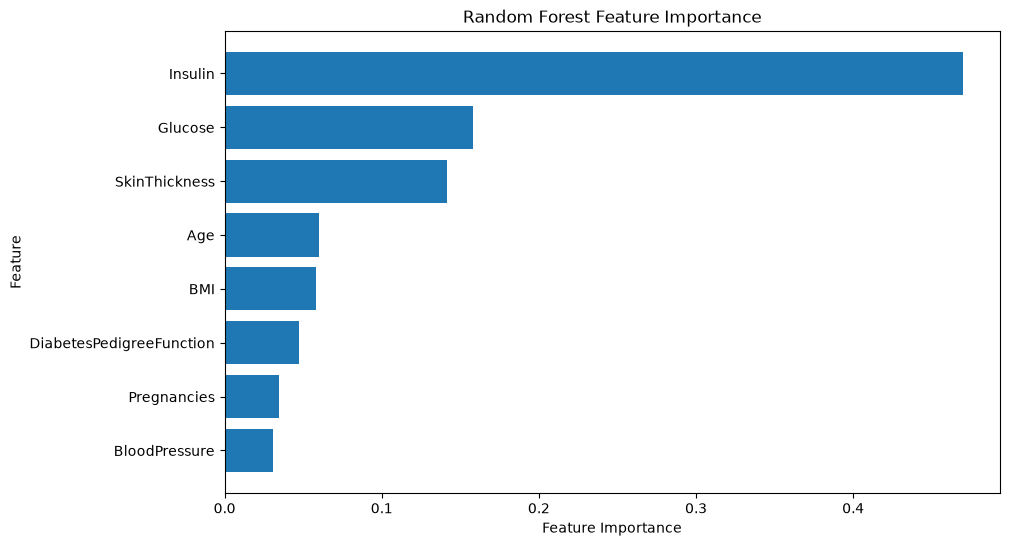

In [91]:
# Plot Feature Importances

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

### Permutation Importance

In [92]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

In [93]:
permutation_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

permutation_df = permutation_df.sort_values(
    by="Importance Mean",
    ascending=False
)

permutation_df

,Feature,Importance Mean,Importance Std
4,Insulin,0.246067,0.041302
1,Glucose,0.022367,0.009956
3,SkinThickness,0.016600,0.008143
6,DiabetesPedigreeFunction,0.008889,0.006618
7,Age,0.007578,0.003770
5,BMI,0.005800,0.005227
0,Pregnancies,-0.001111,0.003004
2,BloodPressure,-0.002267,0.002130


In [94]:
df.groupby("Outcome")["Insulin"].describe()

,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,500.0,117.172000,75.685302,15.0,95.0,102.5,105.0,744.0
1,268.0,187.615672,94.114420,14.0,169.5,169.5,169.5,846.0


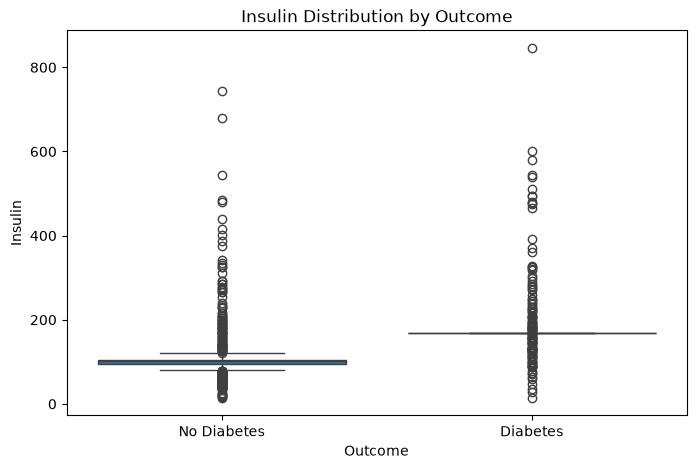

In [95]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Outcome",
    y="Insulin"
)

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.title("Insulin Distribution by Outcome")

plt.show()


### Save Models And Pipeline

In [96]:
# Save the ANN Model

torch.save(
    model.state_dict(),
    "diabetes_ann_best.pth"
)

In [97]:
import os

print(os.path.exists("diabetes_ann_best.pth"))

True


In [98]:
# Save the Tuned Random Forest
import joblib

joblib.dump(
    best_rf,
    "diabetes_random_forest.pkl"
)

print(os.path.exists("diabetes_random_forest.pkl"))

True


In [99]:
# Save Standard Scaler

joblib.dump(
    scaler,
    "standard_scaler.pkl"
)

print(os.path.exists("standard_scaler.pkl"))

True


In [100]:
# Save Model Metadata

import json

model_metadata = {
    "features": list(X_train.columns),
    "random_forest_threshold": 0.30,
    "model": "Tuned Random Forest",
    "test_accuracy": 0.9138,
    "test_precision": 0.8605,
    "test_recall": 0.9024,
    "test_f1_score": 0.8810,
    "test_roc_auc": 0.9551
}

with open("model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

In [101]:
with open("model_metadata.json", "r") as f:
    print(f.read())

{
    "features": [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ],
    "random_forest_threshold": 0.3,
    "model": "Tuned Random Forest",
    "test_accuracy": 0.9138,
    "test_precision": 0.8605,
    "test_recall": 0.9024,
    "test_f1_score": 0.881,
    "test_roc_auc": 0.9551
}


In [102]:
loaded_rf = joblib.load("diabetes_random_forest.pkl")

print(loaded_rf)

RandomForestClassifier(max_depth=15, max_features='log2', min_samples_split=10,
                       n_estimators=500, n_jobs=-1, random_state=42)


In [103]:
loaded_scaler = joblib.load("standard_scaler.pkl")

print(loaded_scaler)

StandardScaler()


In [104]:
with open("model_metadata.json", "r") as f:
    loaded_metadata = json.load(f)

print(loaded_metadata)

{'features': ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], 'random_forest_threshold': 0.3, 'model': 'Tuned Random Forest', 'test_accuracy': 0.9138, 'test_precision': 0.8605, 'test_recall': 0.9024, 'test_f1_score': 0.881, 'test_roc_auc': 0.9551}


In [105]:
# Test Pipeline

sample_index = 0

sample = X_test.iloc[[sample_index]]

print("Original Sample:")
print(sample)

Original Sample:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
83            0      101           65.0             28    102.5  24.6   

    DiabetesPedigreeFunction  Age  
83                     0.237   22  


In [106]:
sample_scaled = loaded_scaler.transform(sample)

In [107]:
sample_scaled = pd.DataFrame(
    loaded_scaler.transform(sample),
    columns=loaded_metadata["features"]
)

In [108]:
sample_probability = loaded_rf.predict_proba(sample_scaled)[:, 1][0]

threshold = loaded_metadata["random_forest_threshold"]

sample_prediction = int(sample_probability >= threshold)

print(f"\nDiabetes Probability: {sample_probability:.4f}")
print(f"Threshold: {threshold}")
print(f"Prediction: {sample_prediction}")
print(f"Actual Label: {y_test.iloc[sample_index]}")


Diabetes Probability: 0.1237
Threshold: 0.3
Prediction: 0
Actual Label: 0


In [109]:
print("Original RF probability on sample:",
      best_rf.predict_proba(sample)[:, 1][0])

print("Original RF probability on scaled sample:",
      best_rf.predict_proba(sample_scaled)[:, 1][0])

Original RF probability on sample: 0.0034929736929736927
Original RF probability on scaled sample: 0.12367630425130428


In [110]:
original_probability = best_rf.predict_proba(sample_scaled)[:, 1][0]

reloaded_probability = loaded_rf.predict_proba(sample_scaled)[:, 1][0]

print(f"Original Model Probability: {original_probability:.10f}")
print(f"Reloaded Model Probability: {reloaded_probability:.10f}")

print("\nDifference:")
print(abs(original_probability - reloaded_probability))

Original Model Probability: 0.1236763043
Reloaded Model Probability: 0.1236763043

Difference:
1.3877787807814457e-17


# Reusable Prediction Pipeline

In [111]:
def predict_diabetes(patient_data, model, scaler, metadata):
    
    # Get required feature order
    features = metadata["features"]
    
    # Convert input dictionary into DataFrame
    patient_df = pd.DataFrame([patient_data])
    
    # Ensure correct feature order
    patient_df = patient_df[features]
    
    # Scale features
    patient_scaled = scaler.transform(patient_df)
    
    # Convert back to DataFrame to preserve feature names
    patient_scaled = pd.DataFrame(
        patient_scaled,
        columns=features
    )
    
    # Predict probability
    probability = float(
        model.predict_proba(patient_scaled)[:, 1][0]
    )
    
    # Apply threshold
    threshold = metadata["random_forest_threshold"]
    
    prediction = int(probability >= threshold)
    
    # Create label
    label = "Diabetes" if prediction == 1 else "No Diabetes"
    
    return {
        "probability": probability,
        "prediction": prediction,
        "label": label,
        "threshold": threshold
    }

In [112]:
sample_patient = X_test.iloc[0].to_dict()

sample_patient

{'Pregnancies': 0.0,
 'Glucose': 101.0,
 'BloodPressure': 65.0,
 'SkinThickness': 28.0,
 'Insulin': 102.5,
 'BMI': 24.6,
 'DiabetesPedigreeFunction': 0.237,
 'Age': 22.0}

In [113]:
result = predict_diabetes(
    sample_patient,
    loaded_rf,
    loaded_scaler,
    loaded_metadata
)

result

{'probability': 0.12367630425130428,
 'prediction': 0,
 'label': 'No Diabetes',
 'threshold': 0.3}